In [2]:
import torch
import torch.nn as nn
from torch.optim import Adam
from torch.utils.data import Dataset, DataLoader
from torchsummary import summary
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(device)

cuda


In [3]:
data_df = pd.read_csv(r"datasets\riceClassification.csv")
data_df.head()

,id,Area,MajorAxisLength,MinorAxisLength,Eccentricity,ConvexArea,EquivDiameter,Extent,Perimeter,Roundness,AspectRation,Class
0,1,4537,92.229316,64.012769,0.719916,4677,76.004525,0.657536,273.085,0.764510,1.440796,1
1,2,2872,74.691881,51.400454,0.725553,3015,60.471018,0.713009,208.317,0.831658,1.453137,1
2,3,3048,76.293164,52.043491,0.731211,3132,62.296341,0.759153,210.012,0.868434,1.465950,1
3,4,3073,77.033628,51.928487,0.738639,3157,62.551300,0.783529,210.657,0.870203,1.483456,1
4,5,3693,85.124785,56.374021,0.749282,3802,68.571668,0.769375,230.332,0.874743,1.510000,1


In [4]:
data_df.dropna(inplace = True)
data_df.drop(['id'], axis=1, inplace=True)
print(data_df.shape)

(18185, 11)


In [5]:
data_df.head()

,Area,MajorAxisLength,MinorAxisLength,Eccentricity,ConvexArea,EquivDiameter,Extent,Perimeter,Roundness,AspectRation,Class
0,4537,92.229316,64.012769,0.719916,4677,76.004525,0.657536,273.085,0.764510,1.440796,1
1,2872,74.691881,51.400454,0.725553,3015,60.471018,0.713009,208.317,0.831658,1.453137,1
2,3048,76.293164,52.043491,0.731211,3132,62.296341,0.759153,210.012,0.868434,1.465950,1
3,3073,77.033628,51.928487,0.738639,3157,62.551300,0.783529,210.657,0.870203,1.483456,1
4,3693,85.124785,56.374021,0.749282,3802,68.571668,0.769375,230.332,0.874743,1.510000,1


In [6]:
print(data_df["Class"].unique())

[1 0]


In [7]:
print(data_df["Class"].value_counts())

Class
1    9985
0    8200
Name: count, dtype: int64


In [8]:
original_df = data_df.copy()

for column in data_df.columns:
    data_df[column] = data_df[column]/data_df[column].abs().max()

data_df.head()

,Area,MajorAxisLength,MinorAxisLength,Eccentricity,ConvexArea,EquivDiameter,Extent,Perimeter,Roundness,AspectRation,Class
0,0.444368,0.503404,0.775435,0.744658,0.424873,0.666610,0.741661,0.537029,0.844997,0.368316,1.0
1,0.281293,0.407681,0.622653,0.750489,0.273892,0.530370,0.804230,0.409661,0.919215,0.371471,1.0
2,0.298531,0.416421,0.630442,0.756341,0.284520,0.546380,0.856278,0.412994,0.959862,0.374747,1.0
3,0.300979,0.420463,0.629049,0.764024,0.286791,0.548616,0.883772,0.414262,0.961818,0.379222,1.0
4,0.361704,0.464626,0.682901,0.775033,0.345385,0.601418,0.867808,0.452954,0.966836,0.386007,1.0


In [9]:
X = np.array(data_df.iloc[:, :-1])
y = np.array(data_df.iloc[:, -1])

In [10]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [11]:
X_test, X_val, y_test, y_val = train_test_split(X_test, y_test, test_size=0.5, random_state=42)

In [12]:
class dataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32).to(device)
        self.y = torch.tensor(y, dtype=torch.float32).to(device)
    
    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, index):
        return self.X[index], self.y[index]


In [13]:
training_data = dataset(X_train, y_train)
validation_data = dataset(X_val, y_val)
testing_data = dataset(X_test, y_test)

In [29]:
train_dataloader = DataLoader(training_data, batch_size = 32, shuffle = True)
validation_dataloader = DataLoader(validation_data, batch_size = 32, shuffle = True)
testing_dataloader = DataLoader(testing_data, batch_size = 32, shuffle = True)

In [15]:
for x, y in train_dataloader:
    print(x)
    print("=====")
    print(y)
    break

tensor([[0.6329, 0.8646, 0.6446, 0.9743, 0.6037, 0.7956, 0.8930, 0.6919, 0.7250,
         0.7610],
        [0.5982, 0.8794, 0.6015, 0.9840, 0.5690, 0.7735, 0.4908, 0.7014, 0.6670,
         0.8295],
        [0.8879, 0.9031, 0.8563, 0.9352, 0.8455, 0.9423, 0.9113, 0.7653, 0.8313,
         0.5983],
        [0.6779, 0.9076, 0.6560, 0.9780, 0.6475, 0.8233, 0.6501, 0.7248, 0.7077,
         0.7850],
        [0.4568, 0.7375, 0.5385, 0.9768, 0.4318, 0.6759, 0.9199, 0.5891, 0.7218,
         0.7770],
        [0.3989, 0.6424, 0.5531, 0.9534, 0.3837, 0.6316, 0.7346, 0.5377, 0.7567,
         0.6590],
        [0.7942, 0.8461, 0.8223, 0.9299, 0.7575, 0.8912, 0.6695, 0.7188, 0.8430,
         0.5838],
        [0.6497, 0.8037, 0.7028, 0.9507, 0.6161, 0.8060, 0.6964, 0.6653, 0.8049,
         0.6488]], device='cuda:0')
=====
tensor([1., 1., 0., 1., 1., 1., 0., 1.], device='cuda:0')


In [16]:
HIDDEN_NEURONS = 10
class MyModel(nn.Module):
    def __init__(self):
        super(MyModel, self).__init__()

        self.input_layer = nn.Linear(
            X.shape[1],
            HIDDEN_NEURONS
        )

        self.linear = nn.Linear(
            HIDDEN_NEURONS, 1
        )

        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.input_layer(x)
        x = self.linear(x)
        x = self.sigmoid(x)
        return x
model = MyModel().to(device)
        

In [17]:
summary(model, (X.shape[1],))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Linear-1                   [-1, 10]             110
            Linear-2                    [-1, 1]              11
           Sigmoid-3                    [-1, 1]               0
Total params: 121
Trainable params: 121
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params size (MB): 0.00
Estimated Total Size (MB): 0.00
----------------------------------------------------------------


In [18]:
criterion = nn.BCELoss()
optimizer = Adam(model.parameters(), lr = 1e-3)

In [35]:
total_loss_train_plot =[]
total_loss_validation_plot = []
total_acc_train_plot = []
total_acc_validation_plot = []

epochs = 10
for epoch in range(epochs):
    total_acc_train = 0
    total_loss_train = 0
    total_acc_val = 0
    total_loss_val = 0


    for data in train_dataloader:
        inputs, labels = data
        prediction = model(inputs).squeeze(1)
        batch_loss = criterion(prediction, labels)

        total_loss_train += batch_loss.item()

        acc = ((prediction).round() == labels).sum().item()

        total_acc_train += acc

        batch_loss.backward()
        optimizer.step()
        optimizer.zero_grad()
        
        
    with torch.no_grad():
        for data in validation_dataloader:
            inputs, labels = data

            prediction = model(inputs).squeeze(1)
            batch_loss = criterion(prediction, labels)

            total_loss_val += batch_loss.item()  
            acc = ((prediction).round() == labels).sum().item()

            total_acc_val += acc

    # ... (Keep the dataloader loops above this exactly the same) ...

    # CORRECTED: Divide by the number of batches to get the true average loss
    avg_train_loss = total_loss_train / len(train_dataloader)
    avg_val_loss = total_loss_val / len(validation_dataloader)
    
    total_loss_train_plot.append(avg_train_loss)
    total_loss_validation_plot.append(avg_val_loss)
    
    # Calculate accuracy percentages
    train_acc_pct = (total_acc_train / len(training_data)) * 100
    val_acc_pct = (total_acc_val / len(validation_data)) * 100
    
    total_acc_train_plot.append(train_acc_pct)
    total_acc_validation_plot.append(val_acc_pct)

    print(f'''Epoch no. {epoch+1} Train Loss: {round(avg_train_loss, 4)} Train Accuracy: {round(train_acc_pct, 4)}
              Validation Loss: {round(avg_val_loss, 4)} Validation Accuracy: {round(val_acc_pct, 4)}''')
    print("="*75)

Epoch no. 1 Train Loss: 0.0416 Train Accuracy: 98.5938
              Validation Loss: 0.0431 Validation Accuracy: 98.6804
Epoch no. 2 Train Loss: 0.0425 Train Accuracy: 98.6252
              Validation Loss: 0.046 Validation Accuracy: 98.3871
Epoch no. 3 Train Loss: 0.0414 Train Accuracy: 98.6095
              Validation Loss: 0.0482 Validation Accuracy: 98.4971
Epoch no. 4 Train Loss: 0.0418 Train Accuracy: 98.6016
              Validation Loss: 0.0431 Validation Accuracy: 98.607
Epoch no. 5 Train Loss: 0.042 Train Accuracy: 98.6488
              Validation Loss: 0.0436 Validation Accuracy: 98.5704
Epoch no. 6 Train Loss: 0.042 Train Accuracy: 98.6095
              Validation Loss: 0.0429 Validation Accuracy: 98.607
Epoch no. 7 Train Loss: 0.0422 Train Accuracy: 98.5309
              Validation Loss: 0.043 Validation Accuracy: 98.607
Epoch no. 8 Train Loss: 0.0416 Train Accuracy: 98.5702
              Validation Loss: 0.0434 Validation Accuracy: 98.5704
Epoch no. 9 Train Loss: 0.0415 

In [36]:
with torch.no_grad():
    total_loss_test = 0
    total_acc_test = 0
    for data in testing_dataloader:
        inputs, labels = data

        prediction = model(inputs).squeeze(1)

        batch_loss_test = criterion(prediction, labels).item()
        total_loss_test += batch_loss_test
        acc = ((prediction).round() == labels).sum().item()

        total_acc_test += acc

print("Accuracy: ", round(total_acc_test/testing_data.__len__() * 100, 4))


Accuracy:  98.8636


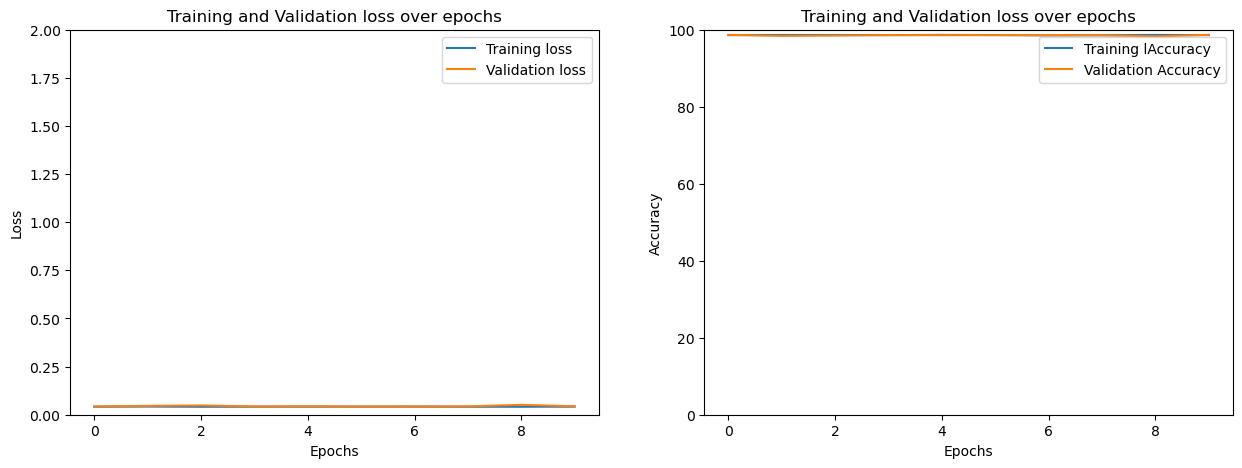

In [ ]:
fig, axs = plt.subplots(nrows=1, ncols=2, figsize = (15, 5))

axs[0].plot(total_loss_train_plot, label = 'Training loss')
axs[0].plot(total_loss_validation_plot, label = 'Validation loss')
axs[0].set_title("Training and Validation loss over epochs")
axs[0].set_xlabel('Epochs')
axs[0].set_ylabel('Loss')
axs[0].set_ylim([0, 2])
axs[0].legend()

axs[1].plot(total_acc_train_plot, label = 'Training lAccuracy')
axs[1].plot(total_acc_validation_plot, label = 'Validation Accuracy')
axs[1].set_title("Training and Validation Accuracy over epochs")
axs[1].set_xlabel('Epochs')
axs[1].set_ylabel('Accuracy')
axs[1].set_ylim([0, 100])
axs[1].legend()


plt.show()
